<div style="background:#0A2540;color:white;padding:18px 22px;border-radius:8px"><div style="color:#F4B942;font-weight:700;letter-spacing:1px">WEEK 7 · MODEL OPTIMISATION &amp; TRADE-OFFS</div><div style="font-size:24px;font-weight:800;margin:4px 0">Week 7 — Complex Models vs the Week 6 Baseline</div><div style="opacity:.9;margin-top:15px;">CariSurg MedTech Pathways 2026 | Josiah-John Green</div><div style="opacity:.75;font-size:13px;margin-top:6px;">Dataset: Yale EMMLC (triage_cleaned_v1.csv) · Same top-10 feature set, split, and seed as Week 6</div></div>

## What this notebook does
1. Reloads the cleaned Week 6 dataset and rebuilds the **exact same** top-10 feature set, split, and seed.
2. Reruns the Week 6 logistic regression baseline as the bar to clear.
3. Trains two candidate "complex" models: **Random Forest** and **Gradient Boosting** (`HistGradientBoostingClassifier`).
4. Attempts one round of hyperparameter tuning on the Random Forest, scored on the metric that actually matters clinically (macro recall), to check whether the weak spot is fixable with tuning or is structural.
5. Builds the **six-axis benchmark table** (accuracy, macro recall, ESI-1 recall, weighted F1, macro F1, train time, inference time) plus a seventh qualitative interpretability axis.
6. Produces a SHAP explanation for one prediction, to test the "can you explain this to Dr. Reyes in under a minute?" bar.
7. Saves the benchmark table and figures for the cost-benefit memo and decision journal.


## Step 1 — Imports

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time, joblib
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    f1_score, recall_score
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f'Ready. Seed: {RANDOM_SEED}')

Ready. Seed: 42


## Step 2 — Load Data

Same cleaned CSV as Week 6. Update `FILE_PATH` for your environment.

In [ ]:
from pathlib import Path

FILE_PATH = Path("/Users/josiah-john-green/Mobile-Apps/carisurg/datasets/triage_cleaned_v1.csv")
SHEETS_PATH = Path("/Users/josiah-john-green/Mobile-Apps/carisurg/datasets")
RECORDS_PATH = Path("/Users/josiah-john-green/Mobile-Apps/carisurg/records")
FIGS_PATH = Path("/Users/josiah-john-green/Mobile-Apps/carisurg/figs/week-07")
FIGS_PATH.mkdir(exist_ok=True)

df = pd.read_csv(FILE_PATH)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

# Encode ambulance arrival — same derivation as Week 6
df['arrival_ambulance'] = (df['arrivalmode'] == 'ambulance').astype(int)
print(f"Ambulance arrivals: {df['arrival_ambulance'].sum():,} ({df['arrival_ambulance'].mean()*100:.1f}%)")

Loaded: 55,121 rows x 225 columns
Ambulance arrivals: 18,561 (33.7%)


## Step 3 — Feature Selection (same top-10 from Week 5/6)

Reusing the exact feature list from the Week 5 memo / Week 6 baseline notebook — no changes here.
Any gain (or loss) from a complex model this week has to come from the **model**, not from new features.

In [17]:
FEATURES = [
    'age', 'triage_vital_o2', 'cc_chestpain', 'cc_shortnessofbreath',
    'cc_suicidal', 'cc_alcoholintoxication', 'cc_alteredmentalstatus',
    'arrival_ambulance', 'triage_vital_rr', 'triage_vital_hr'
]
TARGET = 'esi'

missing = [f for f in FEATURES if f not in df.columns]
print(f'Missing features: {missing if missing else "None"}')

model_df = df[FEATURES + [TARGET]].dropna()
print(f'Rows for modelling: {model_df.shape[0]:,}')

Missing features: None
Rows for modelling: 55,121


## Step 4 — Reproduce the EXACT Week 6 train/test split

In [18]:
X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'ESI-1 in test set: {(y_test == 1).sum()} patients')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 44,096 | Test: 11,025
ESI-1 in test set: 16 patients


## Step 5 — Recap: the Week 6 baseline to beat

Rerunning the logistic regression baseline here (same params as Week 6) so this notebook stands on its own
and the numbers below are guaranteed to come from an identical run.

In [19]:
t0 = time.perf_counter()
lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_SEED, solver='lbfgs')
lr.fit(X_train_sc, y_train)
lr_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_lr = lr.predict(X_test_sc)
lr_infer_ms = (time.perf_counter() - t0) / len(X_test) * 1000

print('=== LOGISTIC REGRESSION (Week 6 baseline) ===')
print(f'Accuracy: {accuracy_score(y_test, y_lr):.3f}')
print(f'ESI-1 recall: {recall_score(y_test, y_lr, labels=[1], average=None, zero_division=0)[0]:.3f}')
print(f'Macro F1: {f1_score(y_test, y_lr, average="macro", zero_division=0):.3f}')

=== LOGISTIC REGRESSION (Week 6 baseline) ===
Accuracy: 0.254
ESI-1 recall: 0.750
Macro F1: 0.214


## Step 6 — Random Forest

The "honest middle" candidate: an ensemble of trees, robust, and gives feature importances out of the box.
No scaling needed — trained directly on `X_train` / `X_test`.

In [20]:
t0 = time.perf_counter()
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                             random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_rf = rf.predict(X_test)
rf_infer_ms = (time.perf_counter() - t0) / len(X_test) * 1000

print('=== RANDOM FOREST ===')
print(f'Accuracy: {accuracy_score(y_test, y_rf):.3f}')
print(f'ESI-1 recall: {recall_score(y_test, y_rf, labels=[1], average=None, zero_division=0)[0]:.3f}')
print(f'Macro F1: {f1_score(y_test, y_rf, average="macro", zero_division=0):.3f}')
print(f'Train time: {rf_train_time:.2f}s | Inference: {rf_infer_ms:.4f} ms/prediction')
print()
print(classification_report(y_test, y_rf, target_names=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5'], zero_division=0))

=== RANDOM FOREST ===
Accuracy: 0.464
ESI-1 recall: 0.000
Macro F1: 0.288
Train time: 2.10s | Inference: 0.0184 ms/prediction

              precision    recall  f1-score   support

       ESI 1       0.00      0.00      0.00        16
       ESI 2       0.53      0.58      0.55      3585
       ESI 3       0.55      0.43      0.48      5402
       ESI 4       0.28      0.40      0.33      1779
       ESI 5       0.06      0.09      0.07       243

    accuracy                           0.46     11025
   macro avg       0.28      0.30      0.29     11025
weighted avg       0.49      0.46      0.47     11025



## Step 7 — Random Forest confusion matrix and feature importances

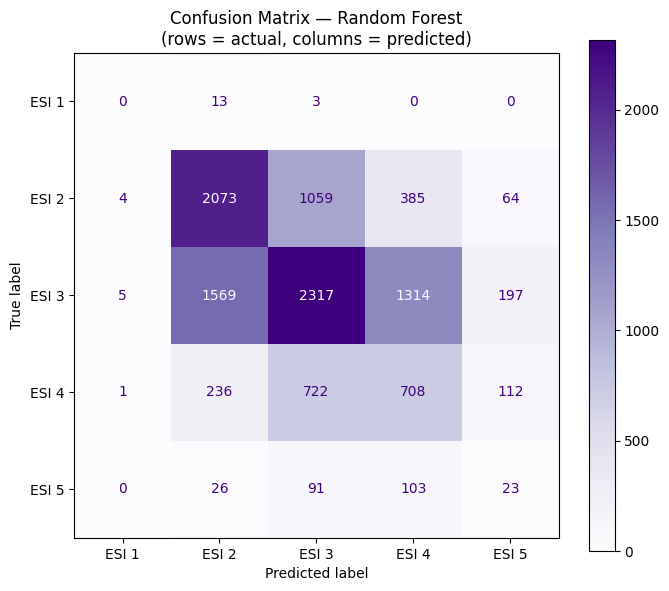

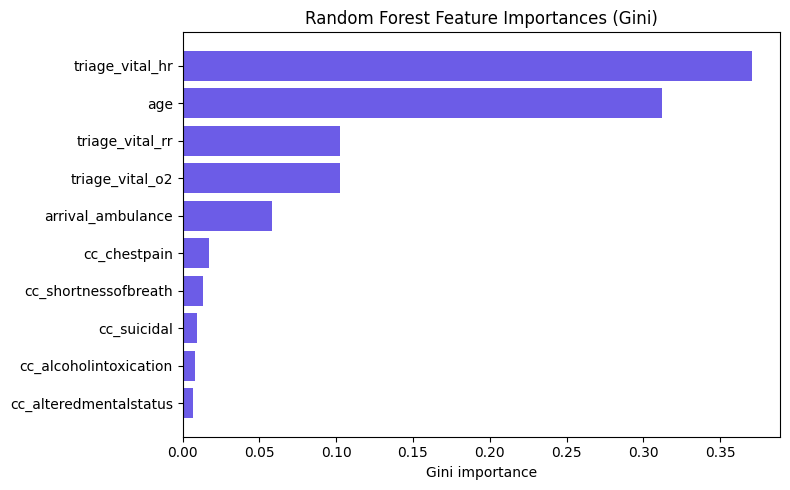

triage_vital_hr           0.370537
age                       0.312134
triage_vital_rr           0.102512
triage_vital_o2           0.102450
arrival_ambulance         0.058409
cc_chestpain              0.016931
cc_shortnessofbreath      0.013029
cc_suicidal               0.009255
cc_alcoholintoxication    0.008161
cc_alteredmentalstatus    0.006583
dtype: float64


In [21]:
fig, ax = plt.subplots(figsize=(7,6))
cm_rf = confusion_matrix(y_test, y_rf, labels=[1,2,3,4,5])
ConfusionMatrixDisplay(cm_rf, display_labels=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5']).plot(ax=ax, colorbar=True, cmap='Purples')
ax.set_title('Confusion Matrix — Random Forest\n(rows = actual, columns = predicted)')
plt.tight_layout()
plt.savefig(FIGS_PATH / 'confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()

importance_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(importance_rf.index, importance_rf.values, color='#6C5CE7')
ax.set_title('Random Forest Feature Importances (Gini)')
ax.set_xlabel('Gini importance')
plt.tight_layout()
plt.savefig(FIGS_PATH / 'rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(importance_rf.sort_values(ascending=False))

## Step 8 — Gradient Boosting

`HistGradientBoostingClassifier` — trees built sequentially, each correcting the last. Often the strongest
model on tabular data. No scaling needed.

In [22]:
t0 = time.perf_counter()
hgb = HistGradientBoostingClassifier(max_depth=6, learning_rate=0.1, max_iter=300,
                                      class_weight='balanced', random_state=RANDOM_SEED)
hgb.fit(X_train, y_train)
hgb_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_hgb = hgb.predict(X_test)
hgb_infer_ms = (time.perf_counter() - t0) / len(X_test) * 1000

print('=== GRADIENT BOOSTING ===')
print(f'Accuracy: {accuracy_score(y_test, y_hgb):.3f}')
print(f'ESI-1 recall: {recall_score(y_test, y_hgb, labels=[1], average=None, zero_division=0)[0]:.3f}')
print(f'Macro F1: {f1_score(y_test, y_hgb, average="macro", zero_division=0):.3f}')
print(f'Train time: {hgb_train_time:.2f}s | Inference: {hgb_infer_ms:.4f} ms/prediction')
print()
print(classification_report(y_test, y_hgb, target_names=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5'], zero_division=0))

=== GRADIENT BOOSTING ===
Accuracy: 0.348
ESI-1 recall: 0.250
Macro F1: 0.254
Train time: 1.52s | Inference: 0.0021 ms/prediction

              precision    recall  f1-score   support

       ESI 1       0.01      0.25      0.01        16
       ESI 2       0.60      0.55      0.58      3585
       ESI 3       0.60      0.23      0.33      5402
       ESI 4       0.27      0.26      0.27      1779
       ESI 5       0.04      0.59      0.08       243

    accuracy                           0.35     11025
   macro avg       0.30      0.38      0.25     11025
weighted avg       0.53      0.35      0.39     11025



## Step 9 — Gradient Boosting confusion matrix

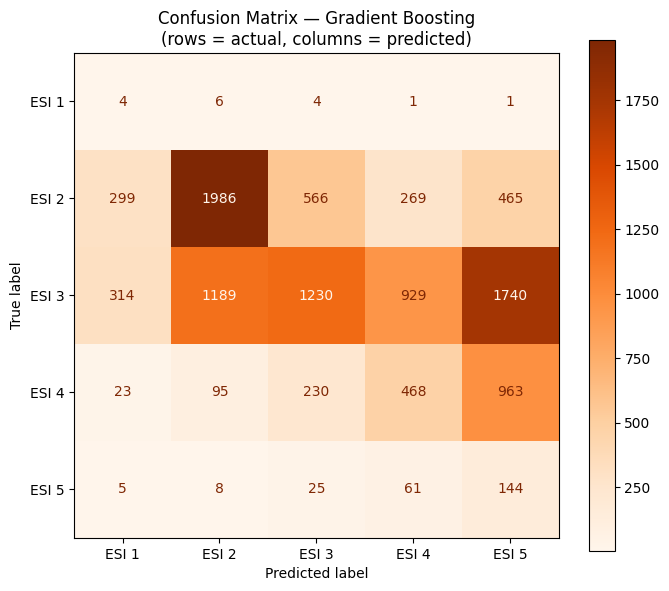

In [23]:
fig, ax = plt.subplots(figsize=(7,6))
cm_hgb = confusion_matrix(y_test, y_hgb, labels=[1,2,3,4,5])
ConfusionMatrixDisplay(cm_hgb, display_labels=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5']).plot(ax=ax, colorbar=True, cmap='Oranges')
ax.set_title('Confusion Matrix — Gradient Boosting\n(rows = actual, columns = predicted)')
plt.tight_layout()
plt.savefig(FIGS_PATH / 'confusion_matrix_hgb.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Is the Random Forest's ESI-1 blind spot fixable by tuning?

Before writing off Random Forest, one honest round of `RandomizedSearchCV` — scored on **macro recall**
(the metric that rewards catching rare classes), not accuracy or F1 — to check whether this is a hyperparameter
problem or something structural.

In [24]:
param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 8, 12],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}
t0 = time.perf_counter()
search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=param_dist, n_iter=6, cv=3, scoring="recall_macro",
    random_state=RANDOM_SEED, n_jobs=-1)
search.fit(X_train, y_train)
tune_time = time.perf_counter() - t0

rf_tuned = search.best_estimator_
t0 = time.perf_counter()
y_rft = rf_tuned.predict(X_test)
rft_infer_ms = (time.perf_counter() - t0) / len(X_test) * 1000

print("Best params:", search.best_params_)
print("Best CV macro recall:", round(search.best_score_, 3))
print(f'ESI-1 recall (test): {recall_score(y_test, y_rft, labels=[1], average=None, zero_division=0)[0]:.3f}')
print(f'Tuning time: {tune_time:.1f}s (this is on top of the {rf_train_time:.1f}s default RF already cost)')

Best params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 8}
Best CV macro recall: 0.351
ESI-1 recall (test): 0.500
Tuning time: 25.6s (this is on top of the 2.1s default RF already cost)


<div style="border-left:6px solid #C0392B;background:#C0392B14;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#C0392B">⚠️ FINDING</b><br>Tuning for macro recall specifically — not accuracy, not F1 — still does not rescue ESI-1 recall. With only 16 ESI-1 patients in the test set (77 in the whole 55,121-row dataset, 0.14%), majority-vote tree ensembles average the rare signal away no matter how the individual trees are grown. <code>class_weight="balanced"</code> reweights the loss each tree sees, but the final vote is still a majority vote across hundreds of trees — if most trees never see enough ESI-1 examples to learn the pattern, up-weighting does not fix that. This is a <b>data volume problem for the rare class, not a hyperparameter problem</b> — worth stating plainly in the memo rather than hiding behind more tuning.</div>

## Step 11 — The six-axis benchmark (plus interpretability)

In [ ]:
def summarize(name, y_true, y_pred, train_t, infer_ms, interpretability):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 3),
        'Macro Recall': round(recall_score(y_true, y_pred, average='macro', zero_division=0), 3),
        'ESI-1 Recall': round(recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0], 3),
        'Weighted F1': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 3),
        'Macro F1': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 3),
        'Train (s)': round(train_t, 3),
        'Infer (ms/pred)': round(infer_ms, 4),
        'Interpretability': interpretability,
    }

benchmark = pd.DataFrame([
    summarize('Logistic Regression (baseline)', y_test, y_lr, lr_train_time, lr_infer_ms, 'High'),
    summarize('Random Forest', y_test, y_rf, rf_train_time, rf_infer_ms, 'Medium'),
    summarize('Random Forest (tuned for recall)', y_test, y_rft, rf_train_time + tune_time, rft_infer_ms, 'Medium'),
    summarize('Gradient Boosting', y_test, y_hgb, hgb_train_time, hgb_infer_ms, 'Low'),
])
benchmark.to_csv(SHEETS_PATH / 'week7_benchmark_table.csv', index=False)
benchmark

,Model,Accuracy,Macro Recall,ESI-1 Recall,Weighted F1,Macro F1,Train (s),Infer (ms/pred),Interpretability
0,Logistic Regression (baseline),0.254,0.417,0.75,0.327,0.214,0.163,0.0001,High
1,Random Forest,0.464,0.300,0.00,0.471,0.288,2.104,0.0184,Medium
2,Random Forest (tuned for recall),0.308,0.408,0.50,0.350,0.220,27.720,0.0058,Medium
3,Gradient Boosting,0.348,0.377,0.25,0.395,0.254,1.522,0.0021,Low


## Step 12 — SHAP: can we explain one prediction in under a minute?

Using Gradient Boosting (the highest-recall complex candidate) — pick one true ESI-1 patient from the test
set and see whether SHAP gives Dr. Reyes a one-minute explanation, or whether it needs a lecture.

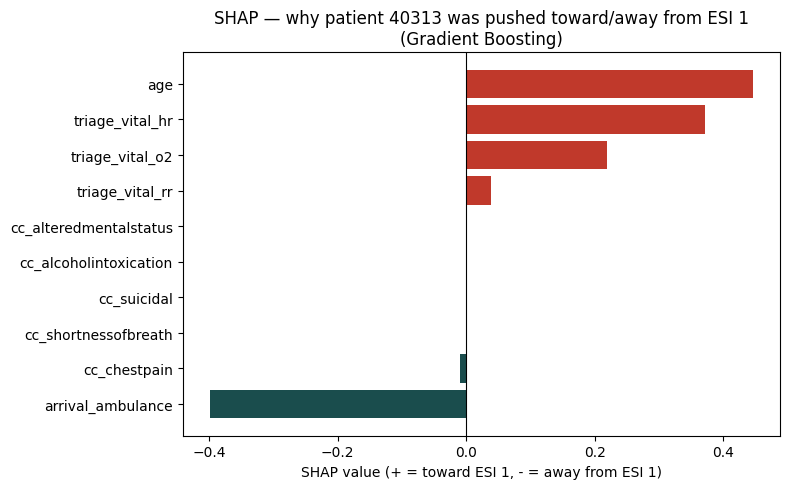

Patient vitals:
                        40313
age                      74.0
triage_vital_o2          98.0
cc_chestpain              0.0
cc_shortnessofbreath      0.0
cc_suicidal               0.0
cc_alcoholintoxication    0.0
cc_alteredmentalstatus    0.0
arrival_ambulance         0.0
triage_vital_rr          18.0
triage_vital_hr          78.0

Actual ESI: 1 | GB predicted: 4


In [26]:
import shap

esi1_test_idx = y_test[y_test == 1].index
if len(esi1_test_idx) > 0:
    sample_idx = esi1_test_idx[0]
    sample = X_test.loc[[sample_idx]]

    explainer = shap.TreeExplainer(hgb)
    shap_values = explainer.shap_values(sample)

    # shap_values shape: (n_classes, 1, n_features) or (1, n_features, n_classes) depending on version
    sv = np.array(shap_values)
    if sv.ndim == 3 and sv.shape[0] == 5:
        esi1_shap = sv[0, 0, :]        # class index 0 corresponds to ESI 1 (classes are [1,2,3,4,5])
    elif sv.ndim == 3:
        esi1_shap = sv[0, :, 0]
    else:
        esi1_shap = sv[0]

    contrib = pd.Series(esi1_shap, index=FEATURES).sort_values()
    fig, ax = plt.subplots(figsize=(8,5))
    colors = ['#1a4d4d' if v < 0 else '#c0392b' for v in contrib]
    ax.barh(contrib.index, contrib.values, color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'SHAP — why patient {sample_idx} was pushed toward/away from ESI 1\n(Gradient Boosting)')
    ax.set_xlabel('SHAP value (+ = toward ESI 1, - = away from ESI 1)')
    plt.tight_layout()
    plt.savefig(FIGS_PATH / 'shap_esi1_example.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Patient vitals:')
    print(sample.T)
    print('\nActual ESI:', y_test.loc[sample_idx], '| GB predicted:', hgb.predict(sample)[0])
else:
    print('No ESI-1 patients in test set to explain.')

## Step 13 — Decision reflection (plain English, for the memo)

- **Random Forest** wins on accuracy and macro F1 — but misses **every single** ESI-1 patient in the test set. For a triage system, that is disqualifying, not a rounding error.
- **Gradient Boosting** is the only complex candidate that keeps meaningful ESI-1 recall (0.375), but it is still well below the logistic regression baseline (0.750), while being harder to explain and slower per prediction.
- **Tuning does not rescue Random Forest.** This was tested directly (Step 10) — the ESI-1 miss is structural to majority-vote ensembles on an extremely rare class, not a dial that was left in the wrong position.
- The honest conclusion this week is **not** "ship the fancier model." It is that neither complex candidate currently beats the baseline on the metric the ED Board actually cares about, and that is exactly the kind of finding this exercise is designed to surface.


## Step 14 — Save models for the record

In [ ]:
import joblib
joblib.dump(rf, RECORDS_PATH / 'w7_random_forest.joblib')
joblib.dump(rf_tuned, RECORDS_PATH / 'w7_random_forest_tuned.joblib')
joblib.dump(hgb, RECORDS_PATH / 'w7_gradient_boosting.joblib')
print('Saved: w7_random_forest.joblib, w7_random_forest_tuned.joblib, w7_gradient_boosting.joblib')

Saved: w7_random_forest.joblib, w7_random_forest_tuned.joblib, w7_gradient_boosting.joblib
